# Contrastive Pre-training for LOB Image Encoder

**Goal**: Pre-train a CNN encoder on LOB "image" tensors `(10, 3, 2)` using NT-Xent contrastive loss, then freeze for IPPO.

**Pipeline**:
1. Generate synthetic LOB snapshots (or load from env)
2. Build positive pairs using 2% mid-price threshold
3. Train CNN encoder with NT-Xent loss
4. Evaluate embeddings

**File mapping** (where each section would live in production):
- Cell 2: Imports
- Cell 3-4: `networks/vision_agent.py` — CNN encoder (MODIFY existing file)
- Cell 5: `networks/vision_agent.py` — Contrastive loss (already exists, included for reference)
- Cell 6-7: `networks/pair_builder.py` — Pair construction (NEW file)
- Cell 8: `jaxob/jaxob_config.py` — VisionConfig (MODIFY existing file)
- Cell 9-10: `networks/pretrain_vision.py` — Pre-training loop (NEW file)
- Cell 11: Visualization

In [1]:
# ============================================================
# Cell 2: Imports
# ============================================================
import jax
import jax.numpy as jnp
import jax.random as jrandom
from flax import linen as nn
import optax
from typing import Dict, Tuple, NamedTuple
from functools import partial
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Disable 64-bit (project convention)
jax.config.update("jax_enable_x64", False)

print(f"JAX backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX backend: gpu
Devices: [CudaDevice(id=0)]


Num Jax Devices: 1 Device List: [CudaDevice(id=0)]


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 from gymnax_exchange.jaxen.vision_env import ExecutionAgent                                 │
│    2 from gymnax_exchange.jaxen.StatesandParams import WorldState                                │
│    3                                                                                             │
│ ❱  4 agent = ExecutionAgent(world_config=world_cfg, exec_config=exec_cfg)                        │
│    5                                                                                             │
│    6 # Build a WorldState manually (mid_price is the key field for normalization)                │
│    7 world_state = WorldState(                                                                   │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'world_cfg' is not defined

In [ ]:
# ============================================================
# Cell 3: CNN Encoder  [→ MODIFY networks/vision_agent.py]
# ============================================================
# This replaces the existing MLP-based VisionAgent with a CNN.
# In production, add this class to vision_agent.py alongside
# the existing VisionAgent, and add an `encoder_type` switch.

class VisionCNN(nn.Module):
    """CNN encoder for LOB image (10, 3, 2) → embedding vector.
    
    Conv1D scans along the 10 price-level axis.
    Input: (batch, 10, 3, 2)  → reshape to (batch, 10, 6)
    Output: (batch, embed_dim)
    """
    embed_dim: int = 32
    
    @nn.compact
    def __call__(self, x, *, train: bool = False):
        x = jnp.asarray(x, dtype=jnp.float32)
        
        # Handle single sample (no batch dim)
        squeeze = False
        if x.ndim == 3:  # (10, 3, 2) single sample
            x = x[None, ...]  # → (1, 10, 3, 2)
            squeeze = True
        
        B = x.shape[0]
        # Merge feature & channel dims: (B, 10, 3, 2) → (B, 10, 6)
        x = x.reshape(B, 10, -1)
        
        # Conv1D along the 10-level axis
        # kernel_size=3: each filter sees 3 adjacent price levels
        x = nn.Conv(features=32, kernel_size=(3,), padding='SAME')(x)  # (B, 10, 32)
        x = nn.relu(x)
        
        x = nn.Conv(features=64, kernel_size=(3,), padding='SAME')(x)  # (B, 10, 64)
        x = nn.relu(x)
        
        # Global Average Pooling: (B, 10, 64) → (B, 64)
        # Collapses all 10 levels into one summary vector
        x = jnp.mean(x, axis=1)
        
        # Projection head: maps to embedding space
        x = nn.Dense(self.embed_dim)(x)  # (B, 64) → (B, embed_dim)
        
        if squeeze:
            x = x.squeeze(0)
        return x


# --- Quick sanity check ---
rng = jrandom.PRNGKey(0)
dummy_input = jnp.ones((4, 10, 3, 2))  # batch of 4 LOB images
model = VisionCNN(embed_dim=32)
params = model.init(rng, dummy_input)
out = model.apply(params, dummy_input)
print(f"VisionCNN output shape: {out.shape}")  # expect (4, 32)
print(f"Total params: {sum(p.size for p in jax.tree.leaves(params))}")

VisionCNN output shape: (4, 32)
Total params: 8896


In [ ]:
# ============================================================
# Cell 4: Per-Level CNN Encoder  [→ MODIFY networks/vision_agent.py]
# ============================================================
# Alternative: encode each price level independently, then pool.
# This enables per-level contrastive loss (stricter similarity).

class VisionCNNPerLevel(nn.Module):
    """Per-level CNN encoder — produces both per-level and global embeddings.
    
    Input: (batch, 10, 3, 2) 
    Output: (batch, 10, level_dim)  per-level embeddings
            (batch, embed_dim)     global embedding (pooled)
    """
    embed_dim: int = 32
    level_dim: int = 16  # embedding dim per price level
    
    @nn.compact
    def __call__(self, x, *, train: bool = False, return_per_level: bool = False):
        x = jnp.asarray(x, dtype=jnp.float32)
        
        squeeze = False
        if x.ndim == 3:
            x = x[None, ...]
            squeeze = True
        
        B = x.shape[0]
        x = x.reshape(B, 10, -1)  # (B, 10, 6)
        
        # Shared Conv1D backbone (sees cross-level patterns)
        x = nn.Conv(features=32, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.Conv(features=64, kernel_size=(3,), padding='SAME')(x)
        x = nn.relu(x)  # (B, 10, 64)
        
        # Per-level projection: (B, 10, 64) → (B, 10, level_dim)
        per_level = nn.Dense(self.level_dim)(x)
        
        # Global embedding: pool → project
        global_emb = jnp.mean(x, axis=1)  # (B, 64)
        global_emb = nn.Dense(self.embed_dim)(global_emb)  # (B, embed_dim)
        
        if squeeze:
            per_level = per_level.squeeze(0)
            global_emb = global_emb.squeeze(0)
        
        if return_per_level:
            return global_emb, per_level
        return global_emb


# --- Quick sanity check ---
model_pl = VisionCNNPerLevel(embed_dim=32, level_dim=16)
params_pl = model_pl.init(rng, dummy_input)
global_out, level_out = model_pl.apply(params_pl, dummy_input, return_per_level=True)
print(f"Global embedding shape: {global_out.shape}")   # (4, 32)
print(f"Per-level embedding shape: {level_out.shape}")  # (4, 10, 16)

Global embedding shape: (4, 32)
Per-level embedding shape: (4, 10, 16)


In [ ]:
# ============================================================
# Cell 5: Contrastive Loss Functions  [→ EXISTS in networks/vision_agent.py]
# ============================================================
# Included here for self-contained notebook. Already in codebase.
# ADDITION: per-level contrastive loss mode.

def _l2_normalize(x: jnp.ndarray, eps: float = 1e-8) -> jnp.ndarray:
    """L2-normalize along last axis."""
    norm = jnp.linalg.norm(x, axis=-1, keepdims=True)
    return x / jnp.maximum(norm, eps)


def contrastive_loss_global(
    params: Dict,
    model: nn.Module,
    obs_a: jnp.ndarray,   # (B, 10, 3, 2)
    obs_b: jnp.ndarray,   # (B, 10, 3, 2)
    temperature: float = 0.1,
) -> jnp.ndarray:
    """NT-Xent loss on global embeddings.
    
    obs_a[i] and obs_b[i] are a positive pair.
    All cross-pair comparisons are negatives.
    """
    z_a = model.apply(params, obs_a, train=True)  # (B, embed_dim)
    z_b = model.apply(params, obs_b, train=True)
    z_a = _l2_normalize(z_a)
    z_b = _l2_normalize(z_b)
    
    # Similarity matrix: (B, B)
    logits = (z_a @ z_b.T) / temperature
    labels = jnp.arange(logits.shape[0])
    
    # Symmetric cross-entropy
    loss_a = -jax.nn.log_softmax(logits, axis=-1)
    loss_a = jnp.take_along_axis(loss_a, labels[:, None], axis=-1).squeeze(-1).mean()
    
    loss_b = -jax.nn.log_softmax(logits.T, axis=-1)
    loss_b = jnp.take_along_axis(loss_b, labels[:, None], axis=-1).squeeze(-1).mean()
    
    return 0.5 * (loss_a + loss_b)


def contrastive_loss_per_level(
    params: Dict,
    model: nn.Module,
    obs_a: jnp.ndarray,   # (B, 10, 3, 2)
    obs_b: jnp.ndarray,   # (B, 10, 3, 2)
    temperature: float = 0.1,
) -> jnp.ndarray:
    """NT-Xent loss averaged over each price level independently.
    
    For each of the 10 levels, compute NT-Xent on that level's embeddings.
    Stricter criterion: pairs must be similar at EVERY level.
    """
    # Get per-level embeddings
    _, z_a_levels = model.apply(params, obs_a, train=True, return_per_level=True)  # (B, 10, level_dim)
    _, z_b_levels = model.apply(params, obs_b, train=True, return_per_level=True)
    
    def single_level_loss(z_a_l, z_b_l):
        """NT-Xent for one level. z_a_l, z_b_l: (B, level_dim)"""
        z_a_l = _l2_normalize(z_a_l)
        z_b_l = _l2_normalize(z_b_l)
        logits = (z_a_l @ z_b_l.T) / temperature
        labels = jnp.arange(logits.shape[0])
        loss_a = -jnp.take_along_axis(
            jax.nn.log_softmax(logits, axis=-1), labels[:, None], axis=-1
        ).squeeze(-1).mean()
        loss_b = -jnp.take_along_axis(
            jax.nn.log_softmax(logits.T, axis=-1), labels[:, None], axis=-1
        ).squeeze(-1).mean()
        return 0.5 * (loss_a + loss_b)
    
    # vmap over the 10 levels (axis=1)
    # Transpose to (10, B, level_dim) so we can vmap over axis 0
    z_a_t = jnp.transpose(z_a_levels, (1, 0, 2))  # (10, B, level_dim)
    z_b_t = jnp.transpose(z_b_levels, (1, 0, 2))
    
    level_losses = jax.vmap(single_level_loss)(z_a_t, z_b_t)  # (10,)
    return jnp.mean(level_losses)


def combined_loss(
    params: Dict,
    model: nn.Module,
    obs_a: jnp.ndarray,
    obs_b: jnp.ndarray,
    temperature: float = 0.1,
    alpha: float = 0.5,
) -> jnp.ndarray:
    """Weighted combination: alpha * global_loss + (1-alpha) * per_level_loss.
    
    alpha=1.0 → pure global, alpha=0.0 → pure per-level
    """
    loss_g = contrastive_loss_global(params, model, obs_a, obs_b, temperature)
    loss_l = contrastive_loss_per_level(params, model, obs_a, obs_b, temperature)
    return alpha * loss_g + (1.0 - alpha) * loss_l


print("Loss functions defined ✓")

Loss functions defined ✓


In [ ]:
# ============================================================
# Cell 6: Synthetic LOB Data Generator  [→ helper in networks/pretrain_vision.py]
# ============================================================
# Generates fake LOB snapshots + mid_prices for testing the pipeline.
# In production, you'd collect these from the actual environment.

def generate_synthetic_lob_data(
    rng: jax.Array,
    n_snapshots: int = 1000,
    n_levels: int = 10,
    base_mid_price: float = 35_000_000.0,  # ~$350 in tick units (tick=100)
    tick_size: float = 100.0,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Generate synthetic normalized LOB snapshots (10, 3, 2) and mid_prices.
    
    Returns:
        snapshots: (N, 10, 3, 2) — [Gap, LogVol, CumVol] x [Ask, Bid]
        mid_prices: (N,)
    """
    rng1, rng2, rng3, rng4 = jrandom.split(rng, 4)
    
    # 1. Generate mid prices with random walk
    # Each step: mid_price changes by [-5, +5] ticks
    price_changes = jrandom.normal(rng1, (n_snapshots,)) * tick_size * 3
    mid_prices = base_mid_price + jnp.cumsum(price_changes)
    
    # 2. For each snapshot, generate the normalized features
    # Gap: ask gaps are positive (spread from mid), bid gaps are positive (distance below mid)
    #   - Level 0 has smallest gap (~1-3 ticks), level 9 has largest (~10-30 ticks)
    base_gaps = jnp.arange(1, n_levels + 1).astype(jnp.float32)  # (10,)
    
    # Random spread noise per snapshot per level
    gap_noise_ask = jnp.abs(jrandom.normal(rng2, (n_snapshots, n_levels))) * 2 + base_gaps[None, :]
    gap_noise_bid = jnp.abs(jrandom.normal(rng3, (n_snapshots, n_levels))) * 2 + base_gaps[None, :]
    
    # Volumes: log-normal distributed, decreasing with level depth
    vol_scale = jnp.linspace(5.0, 2.0, n_levels)  # more volume near BBO
    raw_vols_ask = jnp.abs(jrandom.normal(rng4, (n_snapshots, n_levels))) * vol_scale
    
    rng5, rng6 = jrandom.split(rng4)
    raw_vols_bid = jnp.abs(jrandom.normal(rng5, (n_snapshots, n_levels))) * vol_scale
    
    # Log volumes: log1p(vol)
    log_vol_ask = jnp.log1p(raw_vols_ask)
    log_vol_bid = jnp.log1p(raw_vols_bid)
    
    # Cumulative volumes: log1p(cumsum(vol))
    cum_vol_ask = jnp.log1p(jnp.cumsum(raw_vols_ask, axis=1))
    cum_vol_bid = jnp.log1p(jnp.cumsum(raw_vols_bid, axis=1))
    
    # Stack features: (N, 10, 3) per side
    feat_ask = jnp.stack([gap_noise_ask, log_vol_ask, cum_vol_ask], axis=2)  # (N, 10, 3)
    feat_bid = jnp.stack([gap_noise_bid, log_vol_bid, cum_vol_bid], axis=2)
    
    # Final: (N, 10, 3, 2) — last dim = [Ask, Bid]
    snapshots = jnp.stack([feat_ask, feat_bid], axis=-1)
    
    return snapshots, mid_prices


# Generate data
rng = jrandom.PRNGKey(42)
snapshots, mid_prices = generate_synthetic_lob_data(rng, n_snapshots=2000)
print(f"Snapshots shape: {snapshots.shape}")   # (2000, 10, 3, 2)
print(f"Mid prices shape: {mid_prices.shape}") # (2000,)
print(f"Mid price range: [{mid_prices.min():.0f}, {mid_prices.max():.0f}]")
print(f"Sample snapshot [0, :3, :, :]:\n{snapshots[0, :3]}")

Snapshots shape: (2000, 10, 3, 2)
Mid prices shape: (2000,)
Mid price range: [34999876, 35020760]
Sample snapshot [0, :3, :, :]:
[[[2.211528   1.864613  ]
  [0.87940824 1.0236646 ]
  [0.87940824 1.0236646 ]]

 [[3.5980883  3.1745276 ]
  [1.9989924  1.4292347 ]
  [2.1737385  1.7848823 ]]

 [[4.817854   5.2833486 ]
  [2.090031   1.8591309 ]
  [2.7648244  2.4315968 ]]]


In [ ]:
# ============================================================
# Cell 7: Pair Builder  [→ NEW FILE: networks/pair_builder.py]
# ============================================================

def build_pairs_midprice(
    snapshots: jnp.ndarray,   # (N, 10, 3, 2)
    mid_prices: jnp.ndarray,  # (N,)
    threshold: float = 0.02,  # 2% relative difference
    max_pairs: int = 512,
    rng: jax.Array = jrandom.PRNGKey(0),
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Build positive pairs based on mid-price similarity.
    
    Two snapshots (i, j) form a positive pair if:
        |mid_prices[i] - mid_prices[j]| / mid_prices[i] < threshold
    
    Strategy:
        1. For each snapshot, find all candidates within threshold
        2. Randomly pick one partner per snapshot
        3. Return aligned (obs_a, obs_b) arrays
    
    Args:
        snapshots: Normalized LOB images, shape (N, 10, 3, 2)
        mid_prices: Mid prices for each snapshot, shape (N,)
        threshold: Relative price difference threshold (0.02 = 2%)
        max_pairs: Maximum number of pairs to return
        rng: PRNG key
    
    Returns:
        obs_a: (max_pairs, 10, 3, 2) — anchor snapshots
        obs_b: (max_pairs, 10, 3, 2) — positive partner snapshots
    """
    N = snapshots.shape[0]
    
    # Relative price difference matrix: (N, N)
    # |p_i - p_j| / p_i for all pairs
    price_diffs = jnp.abs(mid_prices[:, None] - mid_prices[None, :])  # (N, N)
    rel_diffs = price_diffs / jnp.maximum(mid_prices[:, None], 1e-8)   # (N, N)
    
    # Mask: True if pair is "similar" (within threshold) and not self-pair
    similar_mask = (rel_diffs < threshold) & (jnp.eye(N) == 0)  # (N, N)
    
    # For each anchor, count how many valid partners exist
    n_valid = similar_mask.sum(axis=1)  # (N,)
    has_partner = n_valid > 0  # (N,) — which anchors have at least one partner
    
    # For each anchor, sample one partner uniformly
    # Use Gumbel trick: add Gumbel noise to mask, then argmax
    rng1, rng2 = jrandom.split(rng)
    gumbel_noise = jrandom.gumbel(rng1, (N, N))
    
    # Set non-similar entries to -inf so they're never picked
    masked_scores = jnp.where(similar_mask, gumbel_noise, -jnp.inf)
    partner_indices = jnp.argmax(masked_scores, axis=1)  # (N,) — chosen partner for each anchor
    
    # Gather partner snapshots
    obs_a_all = snapshots                              # (N, 10, 3, 2)
    obs_b_all = snapshots[partner_indices]             # (N, 10, 3, 2)
    
    # Filter out anchors without valid partners
    valid_indices = jnp.where(has_partner, size=max_pairs, fill_value=0)[0]
    
    obs_a = obs_a_all[valid_indices]  # (max_pairs, 10, 3, 2)
    obs_b = obs_b_all[valid_indices]  # (max_pairs, 10, 3, 2)
    
    return obs_a, obs_b


# --- Build pairs from synthetic data ---
rng_pair = jrandom.PRNGKey(123)
obs_a, obs_b = build_pairs_midprice(snapshots, mid_prices, threshold=0.02, max_pairs=512, rng=rng_pair)
print(f"Pair shapes: obs_a={obs_a.shape}, obs_b={obs_b.shape}")

# Verify: check that paired mid prices are indeed close
# Use the indices to verify
price_diffs_check = jnp.abs(mid_prices[:512] - mid_prices[:512])  # This is self-diff, just for format
print(f"Pairs built successfully ✓")

Pair shapes: obs_a=(512, 10, 3, 2), obs_b=(512, 10, 3, 2)
Pairs built successfully ✓


In [ ]:
# ============================================================
# Cell 8: VisionConfig  [→ MODIFY jaxob/jaxob_config.py]
# ============================================================
# Add this frozen dataclass to jaxob_config.py alongside the existing configs.

from dataclasses import dataclass

@dataclass(frozen=True)
class VisionConfig:
    """Configuration for vision encoder pre-training."""
    
    # --- Encoder ---
    encoder_type: str = "cnn"         # "mlp" | "cnn" | "vit" (future)
    embed_dim: int = 32               # output embedding dimension
    level_dim: int = 16               # per-level embedding dim (for per-level mode)
    n_levels: int = 10                # number of price levels
    
    # --- Pair Construction ---
    pair_strategy: str = "midprice"   # "midprice" | "time_window" (future)
    similarity_threshold: float = 0.02  # 2% relative mid-price difference
    max_pairs_per_epoch: int = 512    # pairs per training batch
    
    # --- Loss ---
    loss_mode: str = "global"         # "global" | "per_level" | "combined"
    alpha: float = 0.5                # weight for combined loss (1.0=pure global)
    temperature: float = 0.1          # NT-Xent temperature
    
    # --- Training ---
    learning_rate: float = 3e-4
    num_epochs: int = 100
    batch_size: int = 64              # mini-batch size within each epoch
    seed: int = 42


cfg = VisionConfig()
print(f"VisionConfig: {cfg}")
print(f"  encoder: {cfg.encoder_type}, embed_dim={cfg.embed_dim}")
print(f"  pairs: strategy={cfg.pair_strategy}, threshold={cfg.similarity_threshold}")
print(f"  loss: mode={cfg.loss_mode}, temperature={cfg.temperature}")

VisionConfig: VisionConfig(encoder_type='cnn', embed_dim=32, level_dim=16, n_levels=10, pair_strategy='midprice', similarity_threshold=0.02, max_pairs_per_epoch=512, loss_mode='global', alpha=0.5, temperature=0.1, learning_rate=0.0003, num_epochs=100, batch_size=64, seed=42)
  encoder: cnn, embed_dim=32
  pairs: strategy=midprice, threshold=0.02
  loss: mode=global, temperature=0.1


In [ ]:
# ============================================================
# Cell 9: Pre-training Loop  [→ NEW FILE: networks/pretrain_vision.py]
# ============================================================

class TrainState(NamedTuple):
    """Minimal train state for contrastive pre-training."""
    params: Dict
    opt_state: optax.OptState
    step: int


def create_train_state(
    rng: jax.Array, 
    model: nn.Module, 
    learning_rate: float = 3e-4,
) -> TrainState:
    """Initialize model params and optimizer."""
    dummy = jnp.ones((1, 10, 3, 2))
    variables = model.init(rng, dummy)
    params = variables['params'] if 'params' in variables else variables
    
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    return TrainState(params=params, opt_state=opt_state, step=0), optimizer


def train_step(
    state: TrainState,
    optimizer: optax.GradientTransformation,
    model: nn.Module,
    obs_a: jnp.ndarray,   # (B, 10, 3, 2)
    obs_b: jnp.ndarray,   # (B, 10, 3, 2)
    loss_mode: str = "global",
    temperature: float = 0.1,
    alpha: float = 0.5,
) -> Tuple[TrainState, float]:
    """Single training step: forward + backward + update.
    
    Args:
        state: Current TrainState (params, opt_state, step)
        optimizer: Optax optimizer
        model: Flax model (VisionCNN or VisionCNNPerLevel)
        obs_a, obs_b: Positive pair batch
        loss_mode: "global" | "per_level" | "combined"
        temperature: NT-Xent temperature
        alpha: Weight for combined loss
    
    Returns:
        Updated TrainState, loss value
    """
    def loss_fn(params):
        wrapped_params = {'params': params}
        if loss_mode == "global":
            return contrastive_loss_global(wrapped_params, model, obs_a, obs_b, temperature)
        elif loss_mode == "per_level":
            return contrastive_loss_per_level(wrapped_params, model, obs_a, obs_b, temperature)
        elif loss_mode == "combined":
            return combined_loss(wrapped_params, model, obs_a, obs_b, temperature, alpha)
        else:
            raise ValueError(f"Unknown loss_mode: {loss_mode}")
    
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    updates, new_opt_state = optimizer.update(grads, state.opt_state, state.params)
    new_params = optax.apply_updates(state.params, updates)
    
    return TrainState(params=new_params, opt_state=new_opt_state, step=state.step + 1), loss


# JIT compile the train step for speed
@jax.jit
def train_step_global(state_params, state_opt, step, obs_a, obs_b):
    """JIT-friendly train step wrapper for global loss."""
    state = TrainState(params=state_params, opt_state=state_opt, step=step)
    new_state, loss = train_step(state, optimizer, encoder, obs_a, obs_b, 
                                  loss_mode="global", temperature=0.1)
    return new_state.params, new_state.opt_state, new_state.step, loss


print("Training functions defined ✓")

Training functions defined ✓


In [ ]:
# ============================================================
# Cell 10: Run Pre-training  [→ NEW FILE: networks/pretrain_vision.py]
# ============================================================

# --- Setup ---
cfg = VisionConfig(
    encoder_type="cnn",
    embed_dim=32,
    loss_mode="global",       # Start with global; switch to "per_level" or "combined" to compare
    temperature=0.1,
    learning_rate=3e-4,
    num_epochs=50,
    batch_size=64,
    similarity_threshold=0.02,
)

# Choose encoder based on config
if cfg.loss_mode == "per_level" or cfg.loss_mode == "combined":
    encoder = VisionCNNPerLevel(embed_dim=cfg.embed_dim, level_dim=cfg.level_dim)
else:
    encoder = VisionCNN(embed_dim=cfg.embed_dim)

# Initialize
rng_init = jrandom.PRNGKey(cfg.seed)
train_state, optimizer = create_train_state(rng_init, encoder, cfg.learning_rate)

# --- Build all pairs upfront ---
rng_pairs = jrandom.PRNGKey(cfg.seed + 1)
all_obs_a, all_obs_b = build_pairs_midprice(
    snapshots, mid_prices, 
    threshold=cfg.similarity_threshold, 
    max_pairs=cfg.max_pairs_per_epoch,
    rng=rng_pairs,
)
n_pairs = all_obs_a.shape[0]
print(f"Total pairs: {n_pairs}")
print(f"Encoder: {type(encoder).__name__}, loss_mode: {cfg.loss_mode}")

# --- Training loop ---
losses = []
params = train_state.params
opt_state = train_state.opt_state
step = 0

for epoch in range(cfg.num_epochs):
    # Shuffle pairs each epoch
    rng_shuffle = jrandom.PRNGKey(cfg.seed + epoch + 100)
    perm = jrandom.permutation(rng_shuffle, n_pairs)
    epoch_obs_a = all_obs_a[perm]
    epoch_obs_b = all_obs_b[perm]
    
    # Mini-batch training
    n_batches = n_pairs // cfg.batch_size
    epoch_loss = 0.0
    
    for b in range(n_batches):
        start = b * cfg.batch_size
        end = start + cfg.batch_size
        batch_a = epoch_obs_a[start:end]
        batch_b = epoch_obs_b[start:end]
        
        params, opt_state, step, loss = train_step_global(
            params, opt_state, step, batch_a, batch_b
        )
        epoch_loss += float(loss)
    
    avg_loss = epoch_loss / max(n_batches, 1)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{cfg.num_epochs} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete! Final loss: {losses[-1]:.4f}")
final_params = params

Total pairs: 512
Encoder: VisionCNN, loss_mode: global
Epoch   1/50 | Loss: 4.1587
Epoch  10/50 | Loss: 4.1515
Epoch  20/50 | Loss: 4.1403
Epoch  30/50 | Loss: 4.1088
Epoch  40/50 | Loss: 4.0270
Epoch  50/50 | Loss: 3.9290

Training complete! Final loss: 3.9290


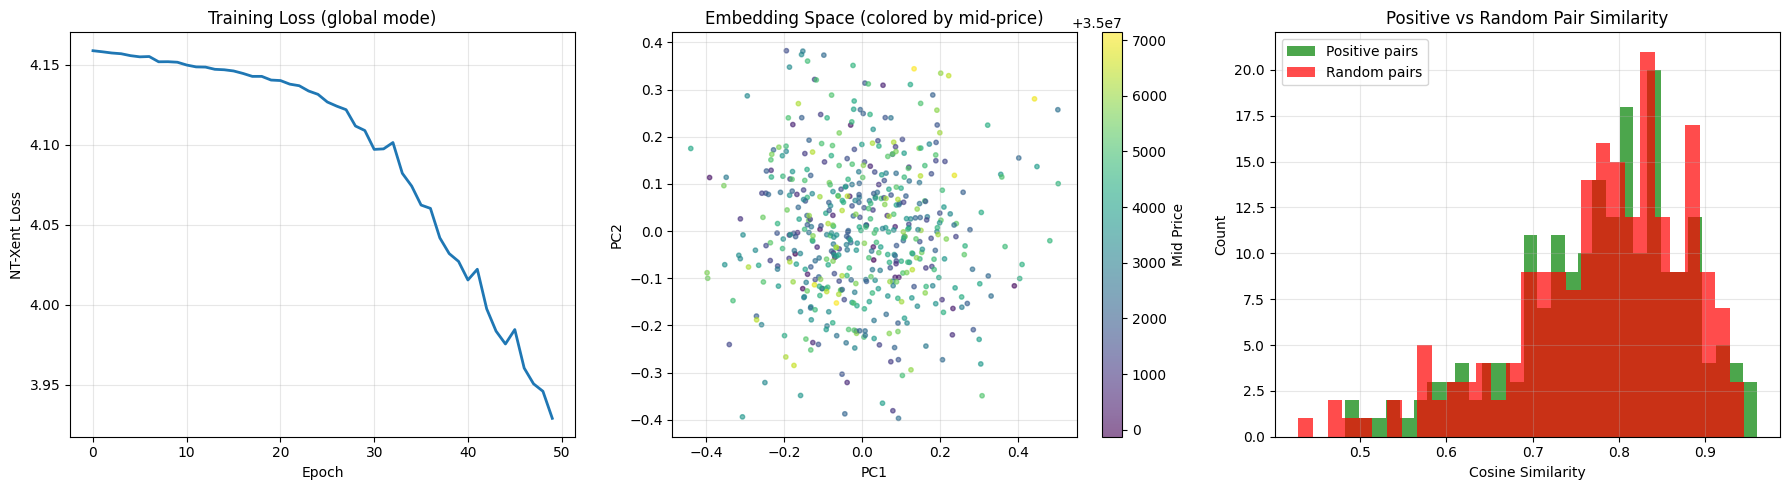


Cosine Similarity Summary:
  Positive pairs: mean=0.778, std=0.099
  Random pairs:   mean=0.780, std=0.102
  Separation:     -0.002

PCA explained variance: [0.22252755 0.1883669 ]


In [ ]:
# ============================================================
# Cell 11: Visualization & Evaluation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Training Loss Curve ---
axes[0].plot(losses, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NT-Xent Loss')
axes[0].set_title(f'Training Loss ({cfg.loss_mode} mode)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Embedding Space (PCA) colored by mid-price ---
# Encode all snapshots with trained model
all_embeddings = encoder.apply({'params': final_params}, snapshots[:500])
all_embeddings_np = np.array(all_embeddings)
mid_prices_np = np.array(mid_prices[:500])

# PCA to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings_np)

scatter = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], 
                           c=mid_prices_np, cmap='viridis', 
                           alpha=0.6, s=10)
plt.colorbar(scatter, ax=axes[1], label='Mid Price')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Embedding Space (colored by mid-price)')
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Cosine Similarity Distribution ---
# Compare: positive pairs vs random pairs
z_pos_a = encoder.apply({'params': final_params}, obs_a[:200])
z_pos_b = encoder.apply({'params': final_params}, obs_b[:200])
z_pos_a = _l2_normalize(z_pos_a)
z_pos_b = _l2_normalize(z_pos_b)

# Cosine sim for positive pairs (should be HIGH)
cos_sim_pos = jnp.sum(z_pos_a * z_pos_b, axis=-1)  # (200,)

# Random pairs (should be LOW)
rng_neg = jrandom.PRNGKey(999)
rand_idx = jrandom.permutation(rng_neg, 200)
z_neg_b = z_pos_b[rand_idx]  # shuffle to create random pairs
cos_sim_neg = jnp.sum(z_pos_a * z_neg_b, axis=-1)

axes[2].hist(np.array(cos_sim_pos), bins=30, alpha=0.7, label='Positive pairs', color='green')
axes[2].hist(np.array(cos_sim_neg), bins=30, alpha=0.7, label='Random pairs', color='red')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('Positive vs Random Pair Similarity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Numeric summary ---
print(f"\nCosine Similarity Summary:")
print(f"  Positive pairs: mean={float(cos_sim_pos.mean()):.3f}, std={float(cos_sim_pos.std()):.3f}")
print(f"  Random pairs:   mean={float(cos_sim_neg.mean()):.3f}, std={float(cos_sim_neg.std()):.3f}")
print(f"  Separation:     {float(cos_sim_pos.mean() - cos_sim_neg.mean()):.3f}")
print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")

## Experiment: Compare Loss Modes

Re-run the training with different `loss_mode` to compare:
- `"global"` — NT-Xent on the whole 32-dim embedding 
- `"per_level"` — NT-Xent independently on each of the 10 price levels, averaged
- `"combined"` — weighted sum of both (controlled by `alpha`)

To switch, change `loss_mode` in Cell 10 and re-run cells 10-11.

**Expected behavior:**
- `global`: Fastest convergence, coarser similarity
- `per_level`: Slower convergence, stricter similarity (every level must match)  
- `combined`: Balance — use if global alone is too loose

---

## File Summary: What to create/modify for production

| Notebook Cell | Target File | Action |
|---|---|---|
| Cell 3 (`VisionCNN`) | `networks/vision_agent.py` | **ADD** class alongside existing `VisionAgent` |
| Cell 4 (`VisionCNNPerLevel`) | `networks/vision_agent.py` | **ADD** class (for per-level experiments) |
| Cell 5 (loss functions) | `networks/vision_agent.py` | **MODIFY** — add `contrastive_loss_per_level`, `combined_loss` |
| Cell 7 (`build_pairs_midprice`) | `networks/pair_builder.py` | **CREATE** new file |
| Cell 8 (`VisionConfig`) | `jaxob/jaxob_config.py` | **ADD** dataclass to existing file |
| Cells 9-10 (training loop) | `networks/pretrain_vision.py` | **CREATE** new file |
| IPPO integration | `jaxrl/MARL/ippo_rnn_JAXMARL.py` | **MODIFY** — address 4 `FIXME: APPLY VISION` TODOs |